# Exercise 1

A mean: 1.8880767304424844
A variance: 1.8613689104419697
B mean: 2.15103458443227
B variance: 2.304344525340553
C mean: 1.8858310479313933
C variance: 2.2536180431819948


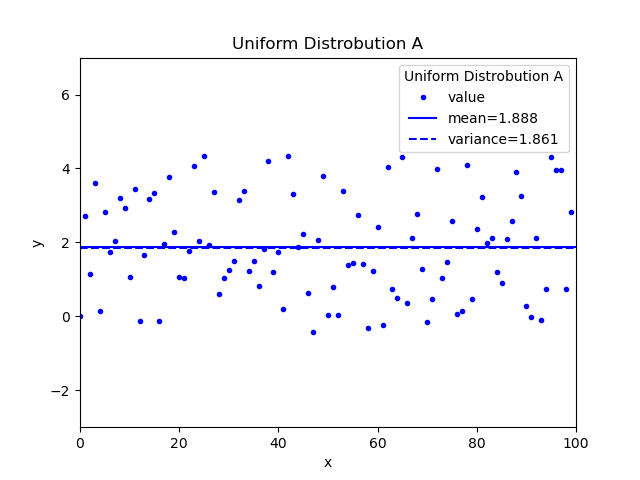

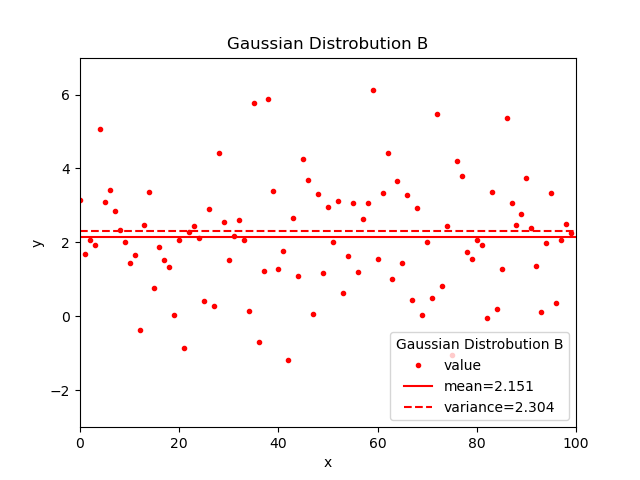

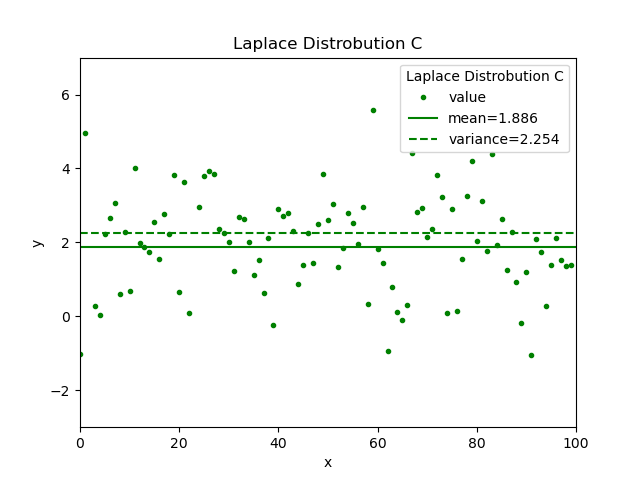

In [56]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import math
import scipy
from IPython.display import display, Markdown, Latex
from scipy import stats

def GenSequenceUniform(n:int, mean:float, variance:float):
    b = mean + math.sqrt(3)*math.sqrt(variance)
    a = mean - math.sqrt(3)*math.sqrt(variance)
    seq = np.random.uniform(a, b, n)
    return seq
def GenSequenceGauss(n, mean, variance):
    return np.random.normal(mean, math.sqrt(variance), n)
def GenSequenceLaplance(n, mean, variance):
    return np.random.laplace(mean, math.sqrt(0.5*variance), n)
def GenSequenceCauchy(n, a, b):
    return stats.cauchy.rvs(a, b, n)

meanABC = 2
varianceABC = 2
nABC = 100

def GenSequencesABCD(n, mean, variance, caucha=2, cauchb=1):
    seqA = GenSequenceUniform(n, mean, variance)
    seqB = GenSequenceGauss(n, mean, variance)
    seqC = GenSequenceLaplance(n, mean, variance)
    seqD = GenSequenceCauchy(n, caucha, cauchb)

    return seqA, seqB, seqC, seqD 
    
seqA, seqB, seqC, seqD = GenSequencesABCD(nABC, meanABC, varianceABC)

print("A mean: " + str(np.mean(seqA)))
print("A variance: " + str(np.var(seqA)))

print("B mean: " + str(np.mean(seqB)))
print("B variance: " + str(np.var(seqB)))

print("C mean: " + str(np.mean(seqC)))
print("C variance: " + str(np.var(seqC)))

def DrawSequenceMeanVariance(seq, name, color, ymn=-3, ymx=7, mark = "."):
    fig = plt.figure()
    plt.axis((0, len(seq), ymn, ymx))
    plt.xlabel("x")
    plt.ylabel("y")
    plt.plot(seq, color + mark, label="value");
    plt.axhline(np.mean(seq), color = color, linestyle = "-",\
                label="mean=" + str(round(np.mean(seq), 3)))
    plt.axhline(np.var(seq), color = color, linestyle = "--",\
                label="variance=" + str(round(np.var(seq), 3)))
    plt.title(name)
    plt.legend(title=name)
    plt.show()
    
DrawSequenceMeanVariance(seqA, "Uniform Distrobution A", "b")
DrawSequenceMeanVariance(seqB, "Gaussian Distrobution B", "r")
DrawSequenceMeanVariance(seqC, "Laplace Distrobution C", "g")


# Exercise 2

D mean: 2.299249926736485
D variance: 2.6661221939339934


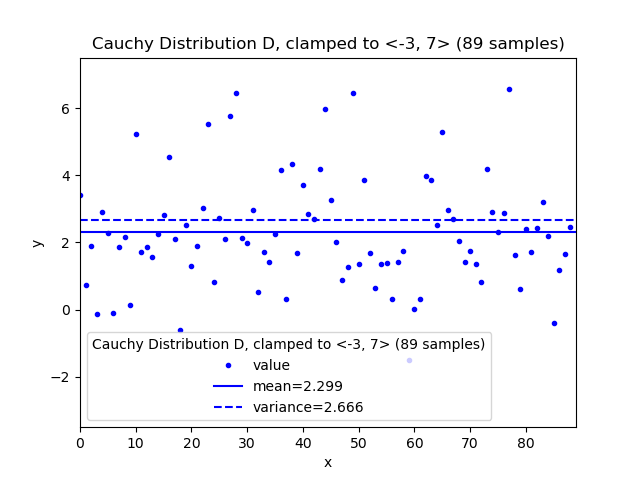

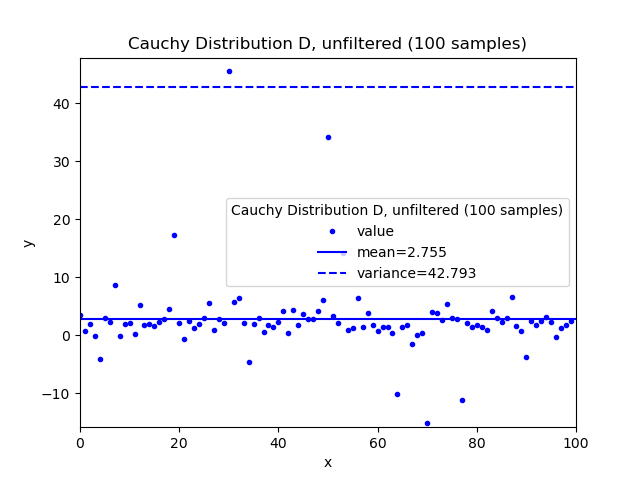

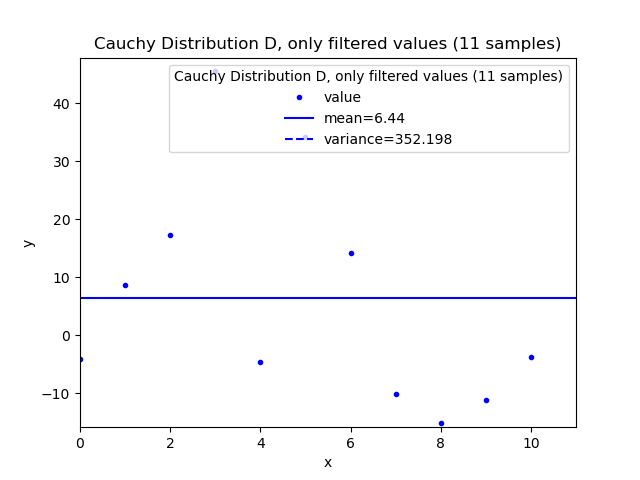

In [51]:
seqDremoved = []
seqDfiltered = []
for x in seqD:
    if (x >= -3 and x <= 7):
        seqDfiltered.append(x)
    else:
        seqDremoved.append(x)
print("D mean: " + str(np.mean(seqDfiltered)))
print("D variance: " + str(np.var(seqDfiltered)))
DrawSequenceMeanVariance(seqDfiltered, "Cauchy Distribution D, clamped to <-3, 7> (" + str(len(seqDfiltered)) + " samples)", "b", -3.5, 7.5)
DrawSequenceMeanVariance(seqD, "Cauchy Distribution D, unfiltered (" + str(len(seqD)) + " samples)", "b", min(seqD) * 1.05, max(seqD) * 1.05)
DrawSequenceMeanVariance(seqDremoved, "Cauchy Distribution D, only filtered values (" + str(len(seqDremoved)) + " samples)", "b", min(seqDremoved) * 1.05, max(seqDremoved) * 1.05)


## Notes:
The distribution tends to generate a number of relatively extreme values that greately affect its variance, though with little effect on the mean.

# Exercise 3

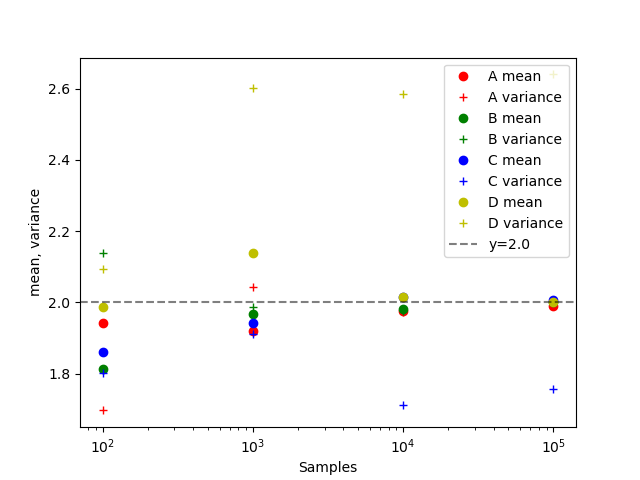

In [28]:
ns = [100, 1000, 10000, 100000]
resultsmean = [[], [], [], []]
resultsvar = [[], [], [], []]
for n in ns:
    seqs = list(GenSequencesABCD(n, meanABC, varianceABC))
    i = 0
    for seq in seqs:
        nseq = [x for x in seq if (x >= -3 and x <= 7)]
        resultsmean[i].append(np.mean(nseq))
        resultsvar[i].append(np.var(nseq))
        i+=1
distnames = ["A", "B", "C", "D"]
distcolors = ["r", "g", "b", "y"]


fig = plt.figure()
plt.title("Variance and mean of distributions A,B,C,D given a various number of samples. All values constrained to <-3, 7>.")
plt.xlabel("Samples")
plt.ylabel("mean, variance")
plt.xscale('log')
for i in range(0, 4):
    plt.plot(ns, resultsmean[i], distcolors[i] + "o", label=distnames[i] + " mean")
    plt.plot(ns, resultsvar[i], distcolors[i] + "+", label=distnames[i] + " variance")
    #print(distnames[i], str(resultsmean[i]), str(resultsvar[i]))
plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
plt.legend()

#fig = plt.figure()
#plt.xlabel("Samples")
#plt.ylabel("mean, variance")
#plt.xscale('log')
#i = 3
#plt.plot(ns, resultsmean[i], distcolors[i] + "o", label=distnames[i] + " mean")
#plt.plot(ns, resultsvar[i], distcolors[i] + "+", label=distnames[i] + " variance")
#plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
#plt.legend()

## Notes:

As expected, both the variance and the mean tend towards the intended value, though the Cautchy distribution's (D) variance tends to diverge quite a lot, desplite the results being constrained to <-3, 7>

# Exercise 4

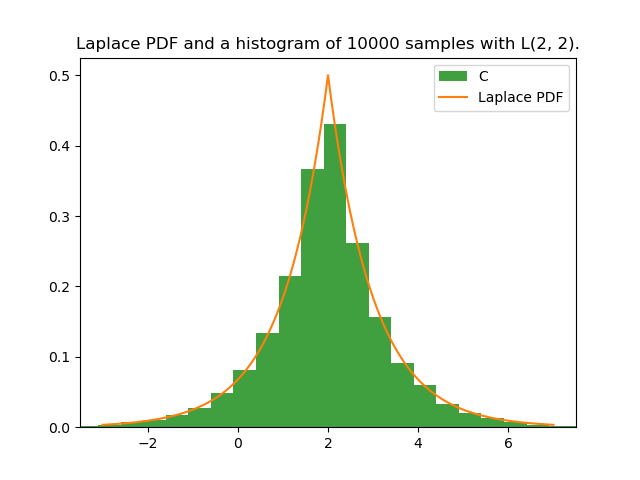

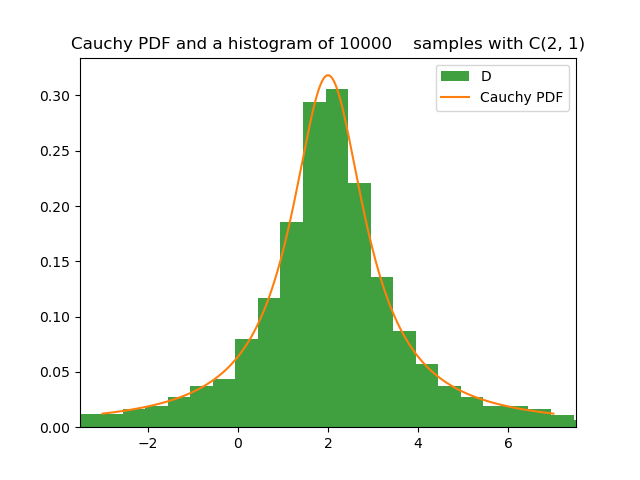

In [66]:
nsamples = 10000

seqA, seqB, seqC, seqD = GenSequencesABCD(nsamples, meanABC, varianceABC)

def ComputeDistribution(npoints, mn, mx, f, a, b):
    ret = []
    points = []
    for i in range(0, npoints):
        p = ((i/npoints) * (mx-mn))+mn
        points.append(p)
        ret.append(f(p, a, b))
    return ret, points
def HistogramCompare(seq, binwidth, points, dist, histlabel, plotlabel, title, axis = (None, None, None, None), color='g', alpha=0.75, show=True):
    fig = plt.figure()
    plt.title(title)
    plt.axis((min(seq) if axis[0] == None else axis[0], max(seq) if axis[1] == None else axis[1], axis[2], axis[3]))
    n, bins, patches = plt.hist(seq, bins=np.arange(min(seq), max(seq) + binwidth, binwidth), density=True, facecolor=color, alpha=alpha, label=histlabel)
    plt.plot(points, dist, label=plotlabel)
    plt.legend()
    if(show):
        plt.show()
    
laplace = lambda x, a, b: (1/(2*b))*(math.e**-(abs(x-a)/b))
cauchy = lambda x, a, b:  (b/math.pi)/(b**2 + (x-a)**2)

distC, pointsC = ComputeDistribution(nsamples, -3, 7, laplace, meanABC, math.sqrt(0.5*varianceABC)) 
distD, pointsD = ComputeDistribution(nsamples, -3, 7, cauchy, 2, 1) 

#print(distC)

#fig = plt.figure()
#plt.title(f"Laplace PDF and a histogram of {len(seqC)} samples with L(2, 2).")
#plt.axis((-3.5, 7.5, None, None))
#n, bins, patches = plt.hist(seqC, bins=np.arange(min(seqC), max(seqC) + 0.5, 0.5), density=True, facecolor='g', alpha=0.75, label="C")
#plt.plot(pointsC, distC, label="laplace PDF")
#plt.legend()

HistogramCompare(seqC, 0.5, pointsC, distC, "C", "Laplace PDF", f"Laplace PDF and a histogram of {len(seqC)} samples with L(2, 2)."\
     , axis = (-3.5, 7.5, None, None))

HistogramCompare(seqD, 0.5, pointsD, distD, "D", "Cauchy PDF", f"Cauchy PDF and a histogram of {len(seqD)}\
    samples with C(2, 1)", axis = (-3.5, 7.5, None, None))




# Exercise 5

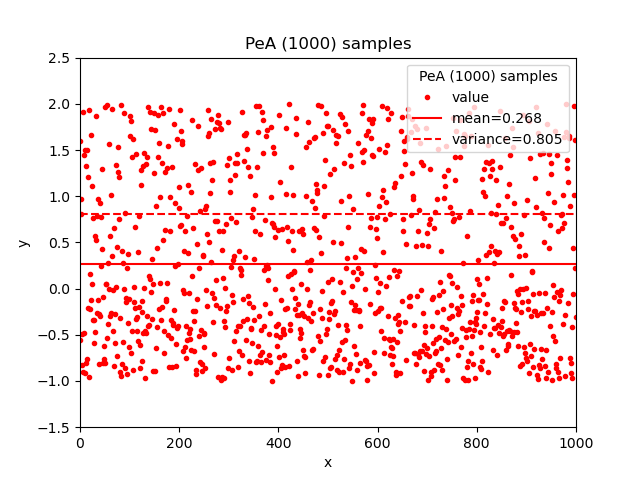

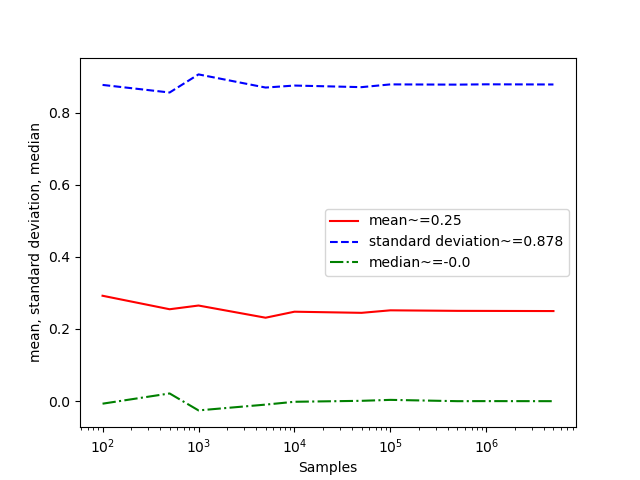

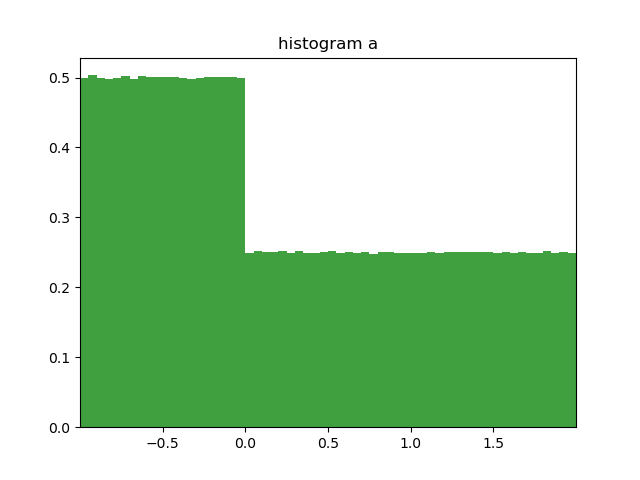

## Conclusions for a:
 Mean tends towards: 0.2
 Standard deviation tends towards: 0.9
 Median tends towards: -0.0


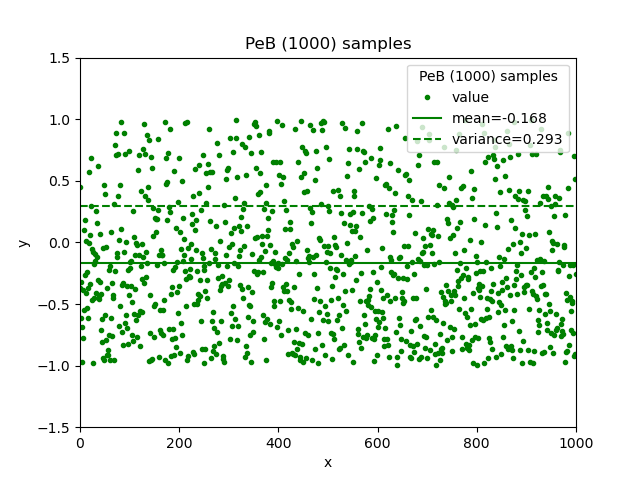

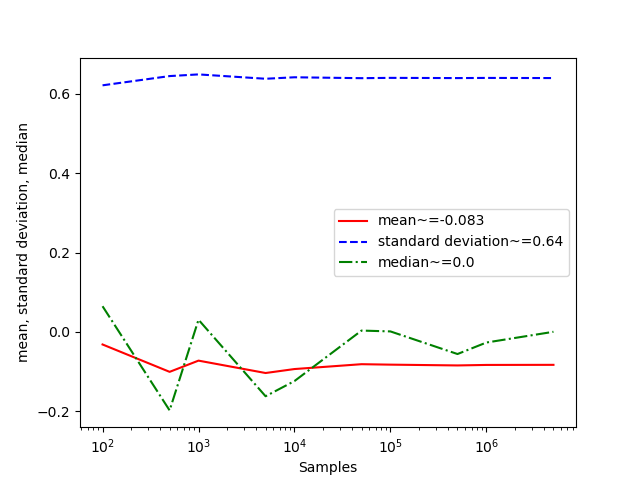

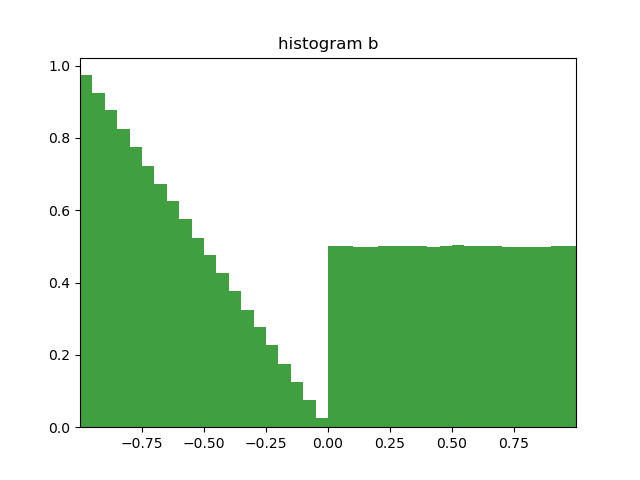

## Conclusions for b:
 Mean tends towards: -0.1
 Standard deviation tends towards: 0.6
 Median tends towards: 0.0


In [83]:
import sys
epsilon = sys.float_info.epsilon

nsamp = 1000

def GenSamplesF(n, f, mn, mx):
    samples = []
    while len(samples) < n:
        #p = ((i/n) * (mx-mn))+mn
        p = np.random.rand() * (mx-mn) + mn
        if(np.random.rand() <= f(p)):
            samples.append(p)
    return samples      
    
def EvaluateFunctionTendencies(f, mn, mx, stages, name):
    fig = plt.figure()
    plt.xlabel("Samples")
    plt.ylabel("mean, standard deviation, median")
    plt.xscale('log')
    resultsmean = []
    resultsdev = []
    resultsmedian = []
    seqs = []
    for stage in stages:
        seq = GenSamplesF(stage, f, mn, mx)
        resultsmean.append(np.mean(seq))
        resultsdev.append(math.sqrt(np.var(seq)))
        resultsmedian.append(np.median(seq))
        seqs.append(seq)
    mean = round(resultsmean[-1], 3);
    dev = round(resultsdev[-1], 3)
    median = round(resultsmedian[-1], 3)
    plt.plot(stages, resultsmean, "r-", label="mean~=" + str(mean))
    plt.plot(stages, resultsdev, "b--", label="standard deviation~=" + str(dev))
    plt.plot(stages, resultsmedian, "g-.", label="median~=" + str(median))
    #plt.axhline(2, color = 'k', linestyle = "--", label="y=2.0", alpha=0.5)
    plt.legend()
    plt.show()

    seq = seqs[-1]
    fig = plt.figure()
    plt.title("histogram " + name)
    plt.axis((min(seq), max(seq), None, None))
    n, bins, patches = plt.hist(seq, bins=np.arange(min(seq), max(seq) + 0.05, 0.05), density=True, facecolor='g', alpha=0.75, label="D")
    #plt.legend()
    plt.show()
    
    mean = round(resultsmean[-1], 1);
    dev = round(resultsdev[-1], 1)
    median = round(resultsmedian[-1], 1)
    
    conclusions = Markdown(f"## Conclusions for {name}:\n Mean tends towards: {mean}\n Standard deviation tends towards: {dev}\n Median tends towards: {median}\n")
    display(conclusions)
    return mean, dev, median

stages = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000, 5000000]

PeA = lambda e: 0.5 if (e > -1 and e < 0) else 0.25 if (e >= 0 and e < 2) else 0

mnA = -1+epsilon
mxA = 2-epsilon
seqA = GenSamplesF(nsamp, PeA, mnA, mxA)
DrawSequenceMeanVariance(seqA, "PeA (" + str(nsamp) + ") samples"  , "r", -1.5, 2.5)

meanA, devA, medianA = EvaluateFunctionTendencies(PeA, mnA, mxA, stages, "a")


PeB = lambda e: -e if (e > -1 and e < 0) else 0.5 if (e >= 0 and e < 1) else 0

mnB = -1+epsilon
mxB = 1-epsilon
seqB = GenSamplesF(nsamp, PeA, mnB, mxB)
DrawSequenceMeanVariance(seqB, "PeB (" + str(nsamp) + ") samples", "g", -1.5, 1.5)

meanB, devB, medianB = EvaluateFunctionTendencies(PeB, mnB, mxB, stages, "b")


## Notes:

# Exercise 6

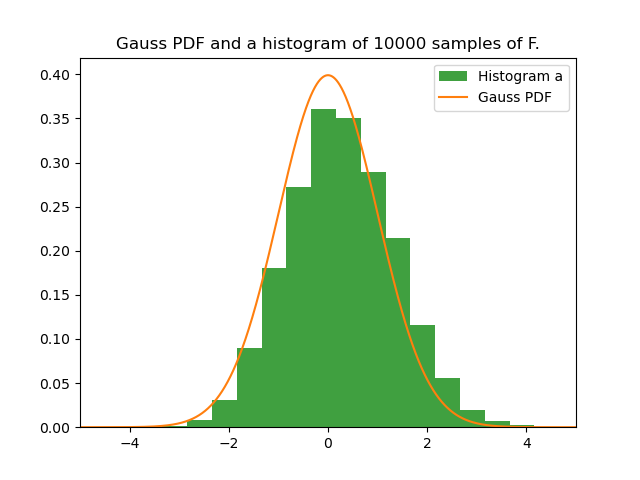

In [84]:
nsamples = 10000

def F6(f, mn, mx, mean, var):
    samples = GenSamplesF(16, f, mn, mx)
    l = [(x - mean)/var for x in samples]
    #print(mean, var)
    #print(l)
    return 0.25 * sum(l)
F6n = lambda n, f, mn, mx, mean, var: [F6(f, mn, mx, mean, var) for i in range(0, n)]

seqPA = F6n(nsamples, PeA, mnA, mxA, meanA, devA**2)


gauss = lambda x, a, b: (1/math.sqrt(2*math.pi*b)) * math.exp(-(x - a)**2 / 2*b)
dist, points = ComputeDistribution(nsamples, -5, 5, gauss, 0, 1) 

HistogramCompare(seqPA, 0.5, points, dist, "Histogram a", "Gauss PDF", f"Gauss PDF and a histogram of {len(seqPA)} samples of F."\
     , axis = (-5, 5, None, None))




## Notes:

# Exercise 7